In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re


import os
import itertools
import cv2
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,  BatchNormalization, Activation, Dropout  
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers,layers, models ,optimizers

import splitfolders
from tensorflow.keras.applications import DenseNet121

from sklearn.utils import class_weight
from collections import Counter

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")




In [2]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)


In [3]:
input_image_size = (224 , 224)  # DensNet121  default input size
batch_size = 4

In [4]:
# load dataset

# Load training dataset without preprocessing
train_ds = datagen.flow_from_directory(
    r"C:\My Folders\Final Year Project\Eye_image_Split\train",
    
    
    batch_size=batch_size,
    target_size=input_image_size,
    class_mode='categorical',
    shuffle=True
    
    
    
)

# Load validation dataset without preprocessing
val_ds = datagen.flow_from_directory(
    r"C:\My Folders\Final Year Project\Eye_image_Split\val",
    
    
    batch_size=batch_size,
    target_size=input_image_size,
    class_mode='categorical',
    
   
)

# Load test dataset without preprocessing
test_ds = datagen.flow_from_directory(
    r"C:\My Folders\Final Year Project\Eye_image_Split\test",
    
    batch_size=batch_size,
    target_size=input_image_size,
    class_mode='categorical',
    shuffle=False,
    
    
)

Found 8560 images belonging to 16 classes.
Found 1828 images belonging to 16 classes.
Found 1852 images belonging to 16 classes.


In [5]:
print("Train Images:", train_ds.samples)
print("Validation Images:", val_ds.samples)
print("Test Images:", test_ds.samples)

Train Images: 8560
Validation Images: 1828
Test Images: 1852


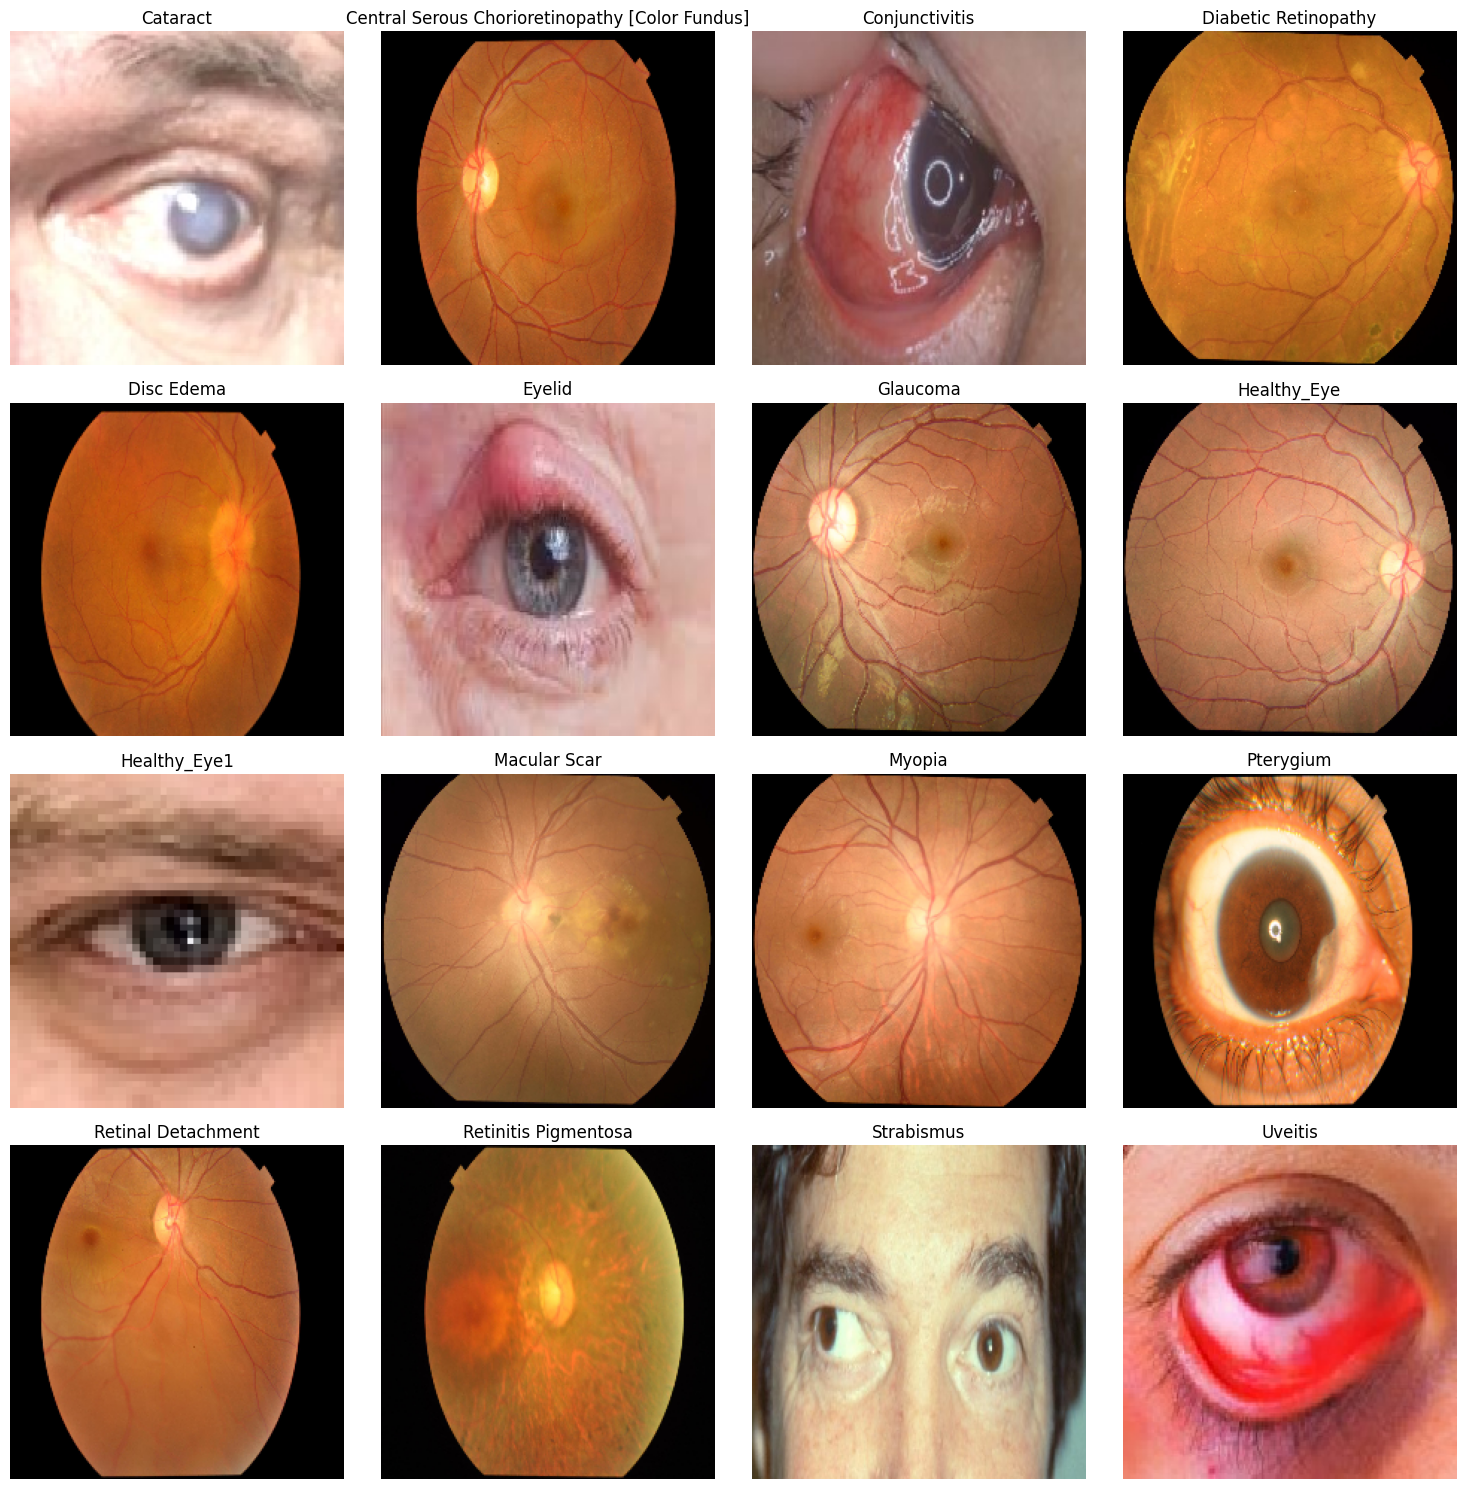

In [6]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

dataset_path = r"C:\My Folders\Final Year Project\Eye_image_split\train"  # Change if needed

class_names = os.listdir(dataset_path)

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(class_names):
    
    class_path = os.path.join(dataset_path, class_name)
    
    # Get random image from that class folder
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    img = image.load_img(img_path, target_size=(224,224))
    
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
dataset_path = r"C:\My Folders\Final Year Project\Eye_Data"   # Change to your dataset path

total_images = 0
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images
        total_images += num_images

print("Total Images:", total_images)
print("\nImages Per Class:")
for k, v in class_counts.items():
    print(f"{k} : {v}")

Total Images: 12240

Images Per Class:
Cataract : 544
Central Serous Chorioretinopathy [Color Fundus] : 707
Conjunctivitis : 357
Diabetic Retinopathy : 1509
Disc Edema : 277
Eyelid : 525
Glaucoma : 1349
Healthy_Eye : 2680
Healthy_Eye1 : 759
Macular Scar : 444
Myopia : 500
Pterygium : 119
Retinal Detachment : 875
Retinitis Pigmentosa : 973
Strabismus : 399
Uveitis : 223


In [8]:
num_classes = len(train_ds.class_indices)
print("Number of classes:", num_classes)

Number of classes: 16


In [9]:
# Get labels
y_train = train_ds.classes

# Check imbalance
print("Class Distribution:", Counter(y_train))

# Compute weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Proper mapping
class_weights = dict(zip(np.unique(y_train), weights))

print("Class Weights:", class_weights)

Class Distribution: Counter({7: 1875, 3: 1056, 6: 944, 13: 681, 12: 612, 8: 531, 1: 494, 0: 380, 5: 367, 10: 350, 9: 310, 14: 279, 2: 249, 4: 193, 15: 156, 11: 83})
Class Weights: {0: 1.4078947368421053, 1: 1.082995951417004, 2: 2.1485943775100402, 3: 0.5066287878787878, 4: 2.772020725388601, 5: 1.457765667574932, 6: 0.5667372881355932, 7: 0.2853333333333333, 8: 1.0075329566854991, 9: 1.7258064516129032, 10: 1.5285714285714285, 11: 6.445783132530121, 12: 0.8741830065359477, 13: 0.7856093979441997, 14: 1.917562724014337, 15: 3.4294871794871793}


In [10]:
# ===================== CALLBACKS =====================
Callback = (

 ModelCheckpoint(
    "DenseNet121_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min'
),
 CSVLogger("DenseNet121_training_Eye.csv", append=True),
ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
))

Early_stop = EarlyStopping(
    patience=8,
    restore_best_weights=True
)
Csv=CSVLogger("DenseNet12_training_Eye1.csv", append=True)


In [11]:
#  Model Construction
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True # Unfreeze for medical fine-tuning

# We freeze the first 100 layers to keep basic edge detectors
for layer in base_model.layers[:100]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Essential for 15 classes to prevent overfitting
    
    layers.Dense(num_classes, activation='softmax')
])

#  Optimizer - Use a lower learning rate than you used before
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()



# ===================train model===========================
history = model.fit(train_ds,
    validation_data=val_ds,
    epochs=20,callbacks=[Csv])

# ================== Fine-tuning (Optional but Recommended) ==================
base_model.trainable = True

# Freeze most layers, train last few
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy",
    tf.keras.metrics.Precision(top_k=1, name='precision'),
    tf.keras.metrics.Recall(top_k=1, name='recall')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,callbacks=Callback)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               524800    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 16)                8

In [12]:
# ===================== TEST EVALUATION =====================
test_results = model.evaluate(test_ds, verbose=1)

print("\nTest Results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

463/463 [==============================] - 41s 88ms/step - loss: 0.3733 - accuracy: 0.8969 - precision: 0.8969 - recall: 0.8969

Test Results:
loss: 0.3733
accuracy: 0.8969
precision: 0.8969
recall: 0.8969


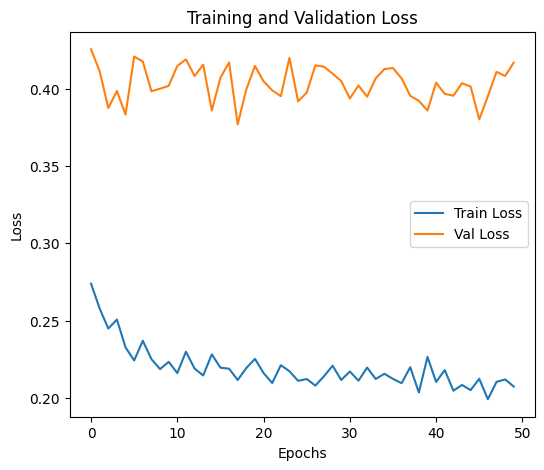

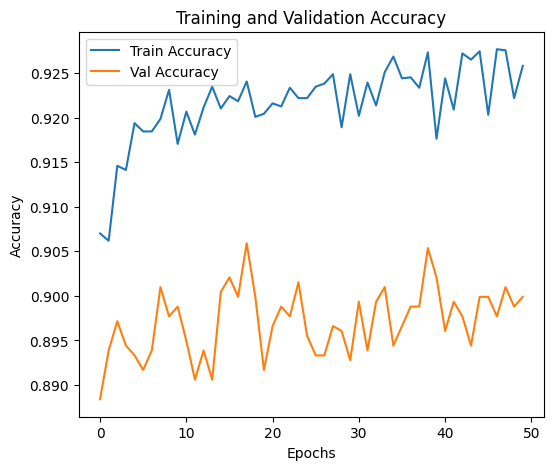

In [13]:
# --------- LOSS PLOT ---------
plt.figure(figsize=(6, 5))
plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.show()

# --------- ACCURACY PLOT ---------
plt.figure(figsize=(6, 5))
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Val Accuracy', 'Best Epoch'])
plt.show()

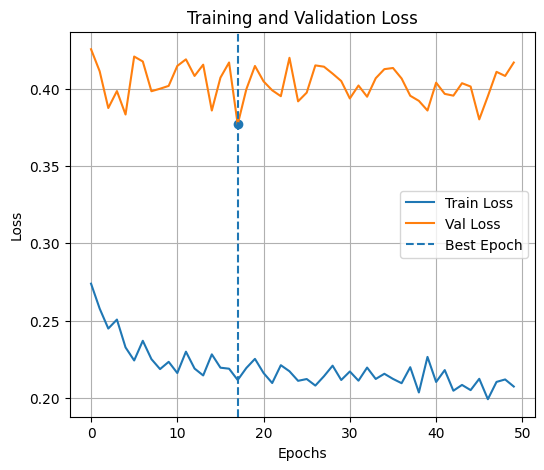

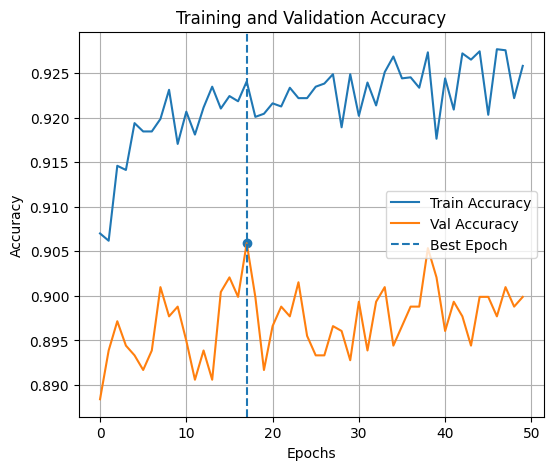

Best Epoch: 18
Best Validation Accuracy: 0.9059


In [14]:


# Get accuracy & loss values
train_acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

train_loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

# Find best epoch (based on validation accuracy)
best_epoch = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch]

epochs_range = range(len(train_acc))

# --------- LOSS PLOT ---------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, train_loss)
plt.plot(epochs_range, val_loss)
plt.axvline(best_epoch, linestyle='--')   # vertical line
plt.scatter(best_epoch, val_loss[best_epoch])  # best point

plt.grid(True)  # 👈 Graph page style background

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss', 'Best Epoch'])
plt.show()

# --------- ACCURACY PLOT ---------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, train_acc)
plt.plot(epochs_range, val_acc)
plt.axvline(best_epoch, linestyle='--')
plt.scatter(best_epoch, best_val_acc)

plt.grid(True)  # 👈 Graph page style background

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Val Accuracy', 'Best Epoch'])
plt.show()

print(f"Best Epoch: {best_epoch+1}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

In [15]:
# Get true labels
y_true = test_ds.classes

# Predict
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(test_ds.class_indices.keys())

463/463 [==============================] - 35s 73ms/step


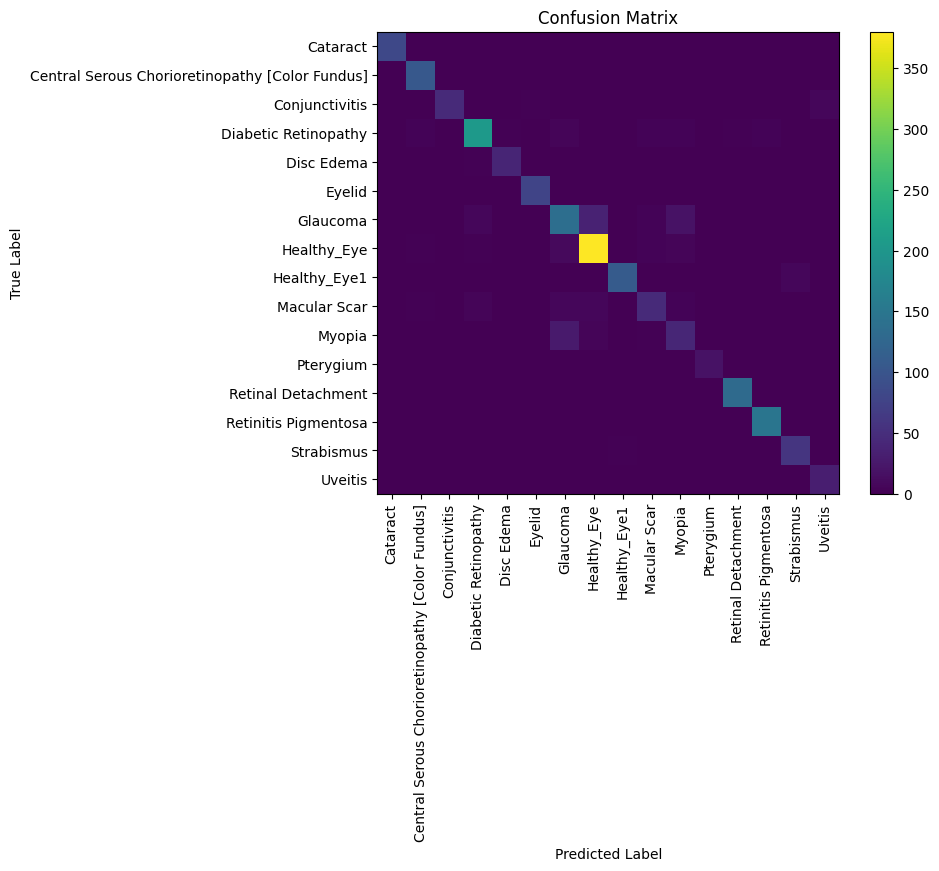

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [17]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

                                                 precision    recall  f1-score   support

                                       Cataract       0.99      1.00      0.99        83
Central Serous Chorioretinopathy [Color Fundus]       0.94      0.98      0.96       107
                                 Conjunctivitis       0.96      0.84      0.89        55
                           Diabetic Retinopathy       0.93      0.90      0.92       227
                                     Disc Edema       0.95      0.93      0.94        43
                                         Eyelid       0.96      0.97      0.97        80
                                       Glaucoma       0.74      0.67      0.71       203
                                    Healthy_Eye       0.88      0.94      0.91       403
                                   Healthy_Eye1       0.98      0.95      0.96       115
                                   Macular Scar       0.75      0.66      0.70       

In [18]:
print("Per-Class Accuracy:\n")

for i in range(len(class_names)):
    class_accuracy = cm[i,i] / np.sum(cm[i])
    print(f"{class_names[i]}: {class_accuracy:.4f}")

Per-Class Accuracy:

Cataract: 1.0000
Central Serous Chorioretinopathy [Color Fundus]: 0.9813
Conjunctivitis: 0.8364
Diabetic Retinopathy: 0.9031
Disc Edema: 0.9302
Eyelid: 0.9750
Glaucoma: 0.6749
Healthy_Eye: 0.9429
Healthy_Eye1: 0.9478
Macular Scar: 0.6618
Myopia: 0.5467
Pterygium: 1.0000
Retinal Detachment: 1.0000
Retinitis Pigmentosa: 1.0000
Strabismus: 0.9508
Uveitis: 0.9412


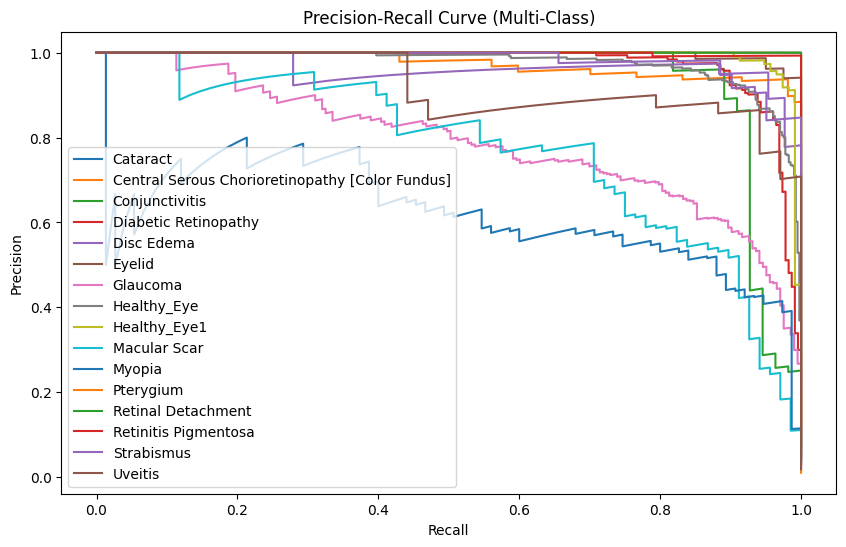

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

plt.figure(figsize=(10,6))

for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Multi-Class)")
plt.legend(loc="best")
plt.show()

In [21]:
print(accuracy_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


0.8947084233261339
[[ 83   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 105   0   0   0   0   0   1   0   1   0   0   0   0   0   0]
 [  0   0  46   0   0   2   0   0   0   0   0   0   0   0   0   7]
 [  0   3   0 205   2   0   5   0   0   4   3   0   2   3   0   0]
 [  0   0   0   2  40   0   0   1   0   0   0   0   0   0   0   0]
 [  1   0   1   0   0  78   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   6   0   0 137  37   0   4  19   0   0   0   0   0]
 [  0   2   0   2   0   0  10 380   0   4   5   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 109   0   0   0   0   0   6   0]
 [  0   2   0   5   0   0   6   7   0  45   3   0   0   0   0   0]
 [  0   0   0   0   0   0  27   5   0   2  41   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  19   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 132   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 147   0   0]
 [  0   0   0   0   0   0   0   0   2   0  

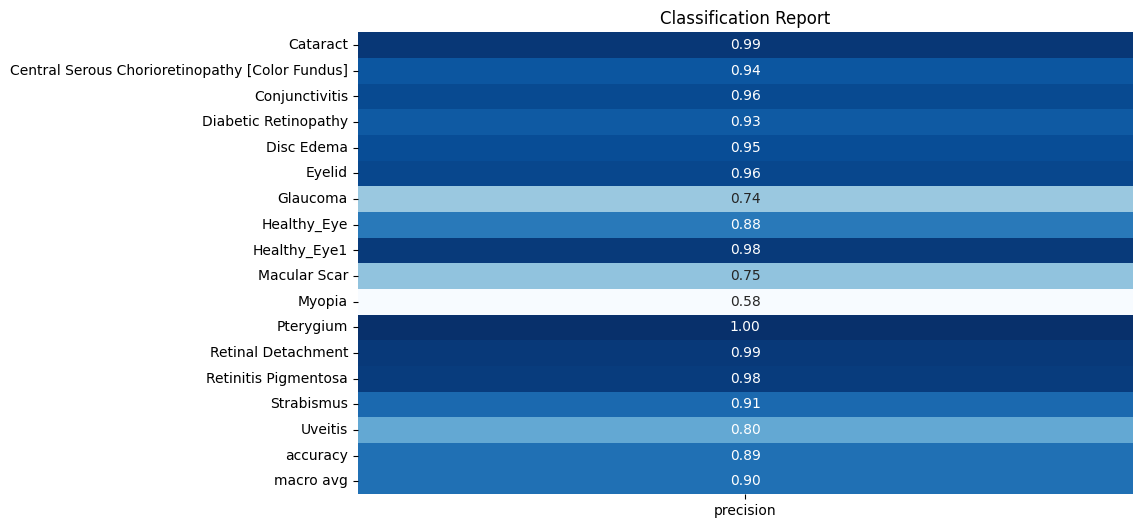

In [22]:
# Classification report show in figure
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(10,6))
sns.heatmap(report_df.iloc[:-1, :-3], annot=True, cmap="Blues", cbar=False, fmt=".2f")
plt.title("Classification Report")
plt.show()


In [23]:
# Class names
class_names = list(test_ds.class_indices.keys())
n_classes = len(class_names)


y_true_bin = label_binarize(y_true, classes=range(n_classes))

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [26]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

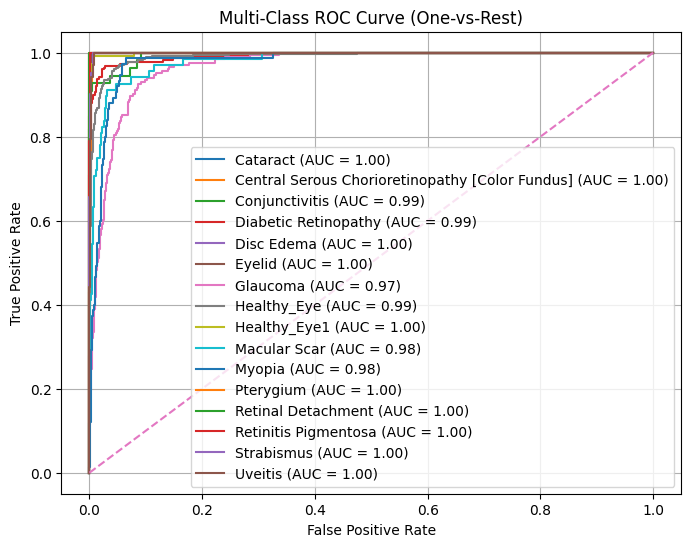

In [27]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Micro-Average ROC (More Professional)

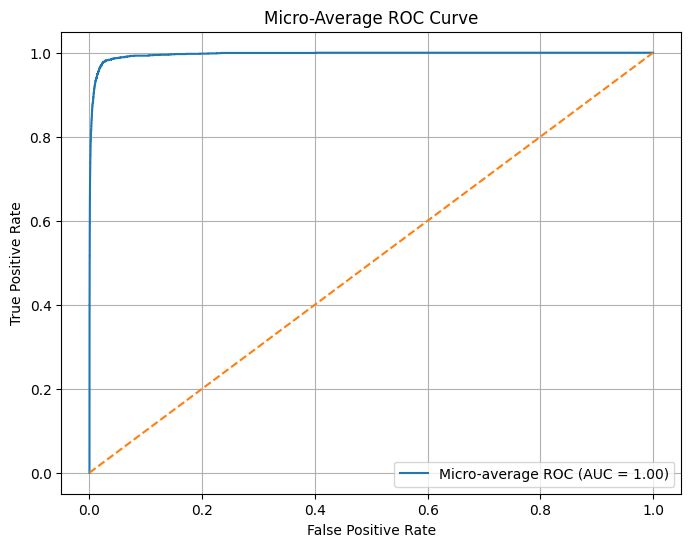

In [28]:
# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(),
                                          y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Average ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Compute Per-Class Accuracy

In [29]:
per_class_accuracy = []

for i in range(len(class_names)):
    acc = cm[i, i] / np.sum(cm[i])
    per_class_accuracy.append(acc)

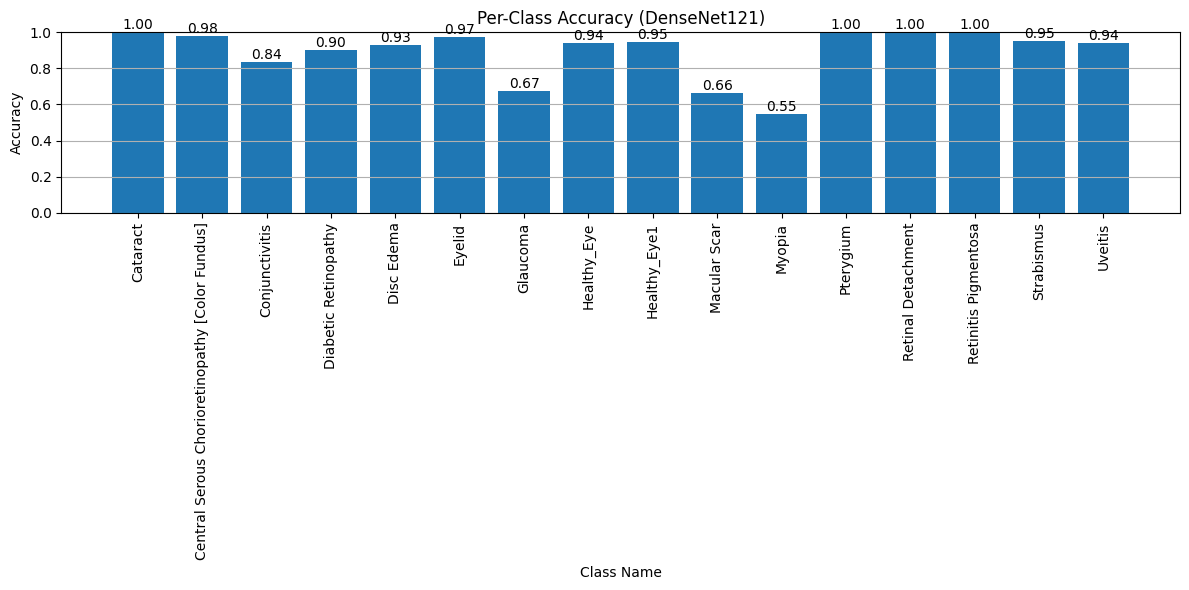

In [30]:
plt.figure(figsize=(12,6))

bars = plt.bar(class_names, per_class_accuracy)

plt.xticks(rotation=90)
plt.xlabel("Class Name")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy (DenseNet121)")
plt.ylim(0,1)
plt.grid(axis='y')

# Add values on top of bars
for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{acc:.2f}",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()

In [31]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("DenseNet121_model.keras")

# Class names
class_names = [
    "Cataract",
    "Central Serous Chorioretinopathy [Color Fundus]",
    "Conjunctivitis",
    "Diabetic Retinopathy",
    "Disc Edema",
    "Eyelid",
    "Glaucoma",
    "Healthy_Eye",
    "Macular Scar",
    "Myopia",
    "Pterygium",
    "Retinal Detachment",
    "Retinitis Pigmentosa",
    "Strabismus",
    "Uveitis"
]

# Load image
img = Image.open(r"C:\My Folders\Final Year Project\Eye_Data_Splits\test\Myopia\Myopia435.jpg")

# IMPORTANT: Convert to RGB
img = img.convert("RGB")

# IMPORTANT: Resize to 224x224
img = img.resize((224, 224))

# Convert to array
img = np.array(img)

# Normalize
img = img / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted:", class_names[predicted_class])
print("Confidence:", round(confidence * 100, 2), "%")

1/1 [==============================] - 3s 3s/step
Predicted: Pterygium
Confidence: 58.53 %
